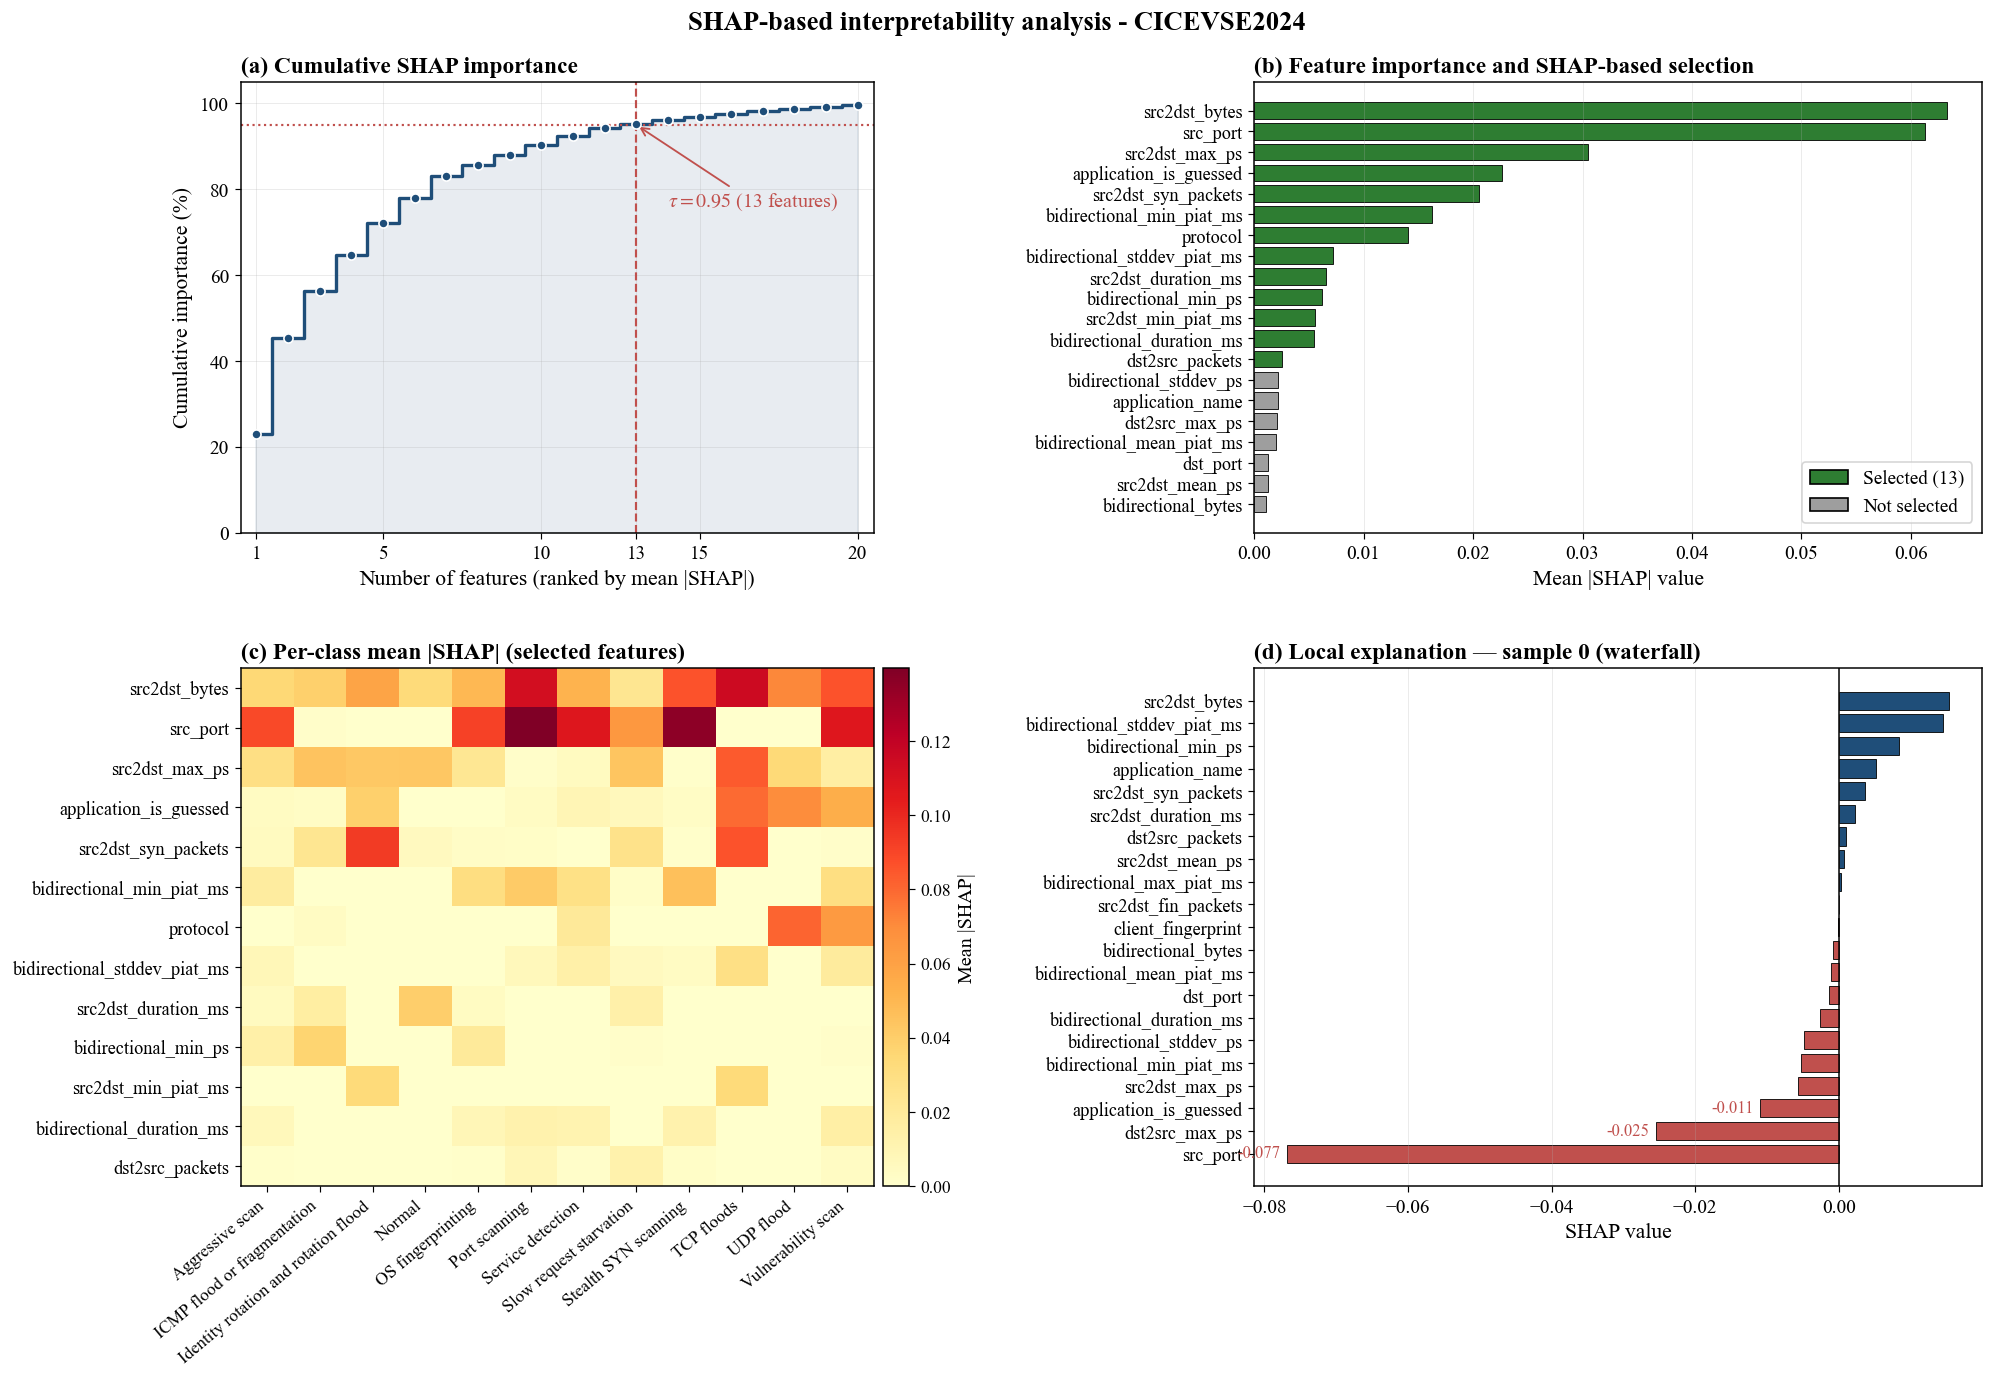

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Global style: Times New Roman, larger text, tighter spacing
# ------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "legend.fontsize": 11.5,
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

DATASET_TAG = "CICEVSE2024"
PRIMARY   = "#1f4e79"
ACCENT    = "#c0504d"
SELECTED  = "#2e7d32"
NEUTRAL   = "#9e9e9e"

# ------------------------------------------------------------------
# 1) Cumulative importance data
# ------------------------------------------------------------------
cum = pd.DataFrame({
    "feature": ["src2dst_bytes","src_port","src2dst_max_ps","application_is_guessed",
                "src2dst_syn_packets","bidirectional_min_piat_ms","protocol",
                "bidirectional_stddev_piat_ms","src2dst_duration_ms","bidirectional_min_ps",
                "src2dst_min_piat_ms","bidirectional_duration_ms","dst2src_packets",
                "bidirectional_stddev_ps","application_name","dst2src_max_ps",
                "bidirectional_mean_piat_ms","dst_port","src2dst_mean_ps",
                "bidirectional_bytes"],
    "relative_importance": [0.230077803,0.222737767,0.110777153,0.08232183,0.074740592,
                            0.059054994,0.051094058,0.026093665,0.023981027,0.022442788,
                            0.020134353,0.019972139,0.009125736,0.007929671,0.00786455,
                            0.007640066,0.007240404,0.004629206,0.004512355,0.003968984],
    "cumulative_importance": [0.230077803,0.45281557,0.563592723,0.645914553,0.720655145,
                              0.779710139,0.830804197,0.856897862,0.880878889,0.903321678,
                              0.923456031,0.94342817,0.952553906,0.960483577,0.968348127,
                              0.975988193,0.983228597,0.987857803,0.992370157,0.996339141],
})

# ------------------------------------------------------------------
# 2) Feature importance + selected flag
# ------------------------------------------------------------------
feat = pd.DataFrame({
    "feature": ["src2dst_bytes","src_port","src2dst_max_ps","application_is_guessed",
                "src2dst_syn_packets","bidirectional_min_piat_ms","protocol",
                "bidirectional_stddev_piat_ms","src2dst_duration_ms","bidirectional_min_ps",
                "src2dst_min_piat_ms","bidirectional_duration_ms","dst2src_packets",
                "bidirectional_stddev_ps","application_name","dst2src_max_ps",
                "bidirectional_mean_piat_ms","dst_port","src2dst_mean_ps",
                "bidirectional_bytes"],
    "mean_abs_shap": [0.063329866,0.061309491,0.030491869,0.022659424,0.020572657,
                      0.016255131,0.014063851,0.007182389,0.006600877,0.00617747,
                      0.005542064,0.005497414,0.002511897,0.002182675,0.00216475,
                      0.00210296,0.001992951,0.001274208,0.001242044,0.001092479],
    "selected": [True]*13 + [False]*7,
})

# ------------------------------------------------------------------
# 3) Per-class SHAP summary — 13 selected features × 12 classes
# ------------------------------------------------------------------
class_names = ["Aggressive scan","ICMP flood or fragmentation",
               "Identity rotation and rotation flood","Normal",
               "OS fingerprinting","Port scanning","Service detection",
               "Slow request starvation","Stealth SYN scanning",
               "TCP floods","UDP flood","Vulnerability scan"]

per_class_data = {
    "src2dst_bytes":              [0.034869736,0.039214276,0.058667932,0.032758713,0.049232821,0.112235822,0.051498689,0.023663479,0.086153982,0.11463822,0.071316476,0.085708253],
    "src_port":                   [0.08883912,0.001295062,0.0,0.0,0.09131969,0.139672136,0.107408177,0.064839923,0.13565661,1.49e-06,1.32e-18,0.10668169],
    "src2dst_max_ps":             [0.029036604,0.044716119,0.042223751,0.042895581,0.022388388,0.001291784,0.004497528,0.043751328,0.000819221,0.083831059,0.034205183,0.016245885],
    "application_is_guessed":     [0.004321469,0.002790032,0.039073946,0.0,0.000102942,0.003580797,0.009271456,0.00641805,0.003001845,0.079113266,0.069713211,0.054526075],
    "src2dst_syn_packets":        [0.004372061,0.023876811,0.09368059,0.005290901,0.002523206,0.001670861,0.000439984,0.026671659,0.001066411,0.085939633,0.0,0.001339767],
    "bidirectional_min_piat_ms":  [0.017959388,0.0,0.0,0.0,0.030093448,0.041382294,0.027954743,0.001750329,0.046277098,0.0,0.0,0.029644274],
    "protocol":                   [0.0,0.003570339,0.0,0.0,0.0,0.0,0.02067099,0.0,0.0,0.0,0.081017646,0.063507234],
    "bidirectional_stddev_piat_ms":[0.007671054,0.0,0.0,1.68e-19,0.000382833,0.006986153,0.01444645,0.005177536,0.003804146,0.028700757,0.0,0.019019742],
    "src2dst_duration_ms":        [0.004482678,0.01667227,0.0,0.039605262,0.004289456,5.75e-05,2.30e-05,0.0136875,0.0,8.71e-05,0.0,0.000305777],
    "bidirectional_min_ps":       [0.014461627,0.036820791,0.0,0.0,0.019933234,0.000179638,5.65e-05,0.001415116,0.0,2.47e-06,0.0,0.001260312],
    "src2dst_min_piat_ms":        [0.0,0.0,0.033252384,0.0,0.0,0.0,0.0,0.0,0.0,0.033252384,0.0,0.0],
    "bidirectional_duration_ms":  [0.006671778,0.0,0.0,0.0,0.008361987,0.012242007,0.01094241,0.0,0.012032065,0.0,0.0,0.01571872],
    "dst2src_packets":            [0.001028353,0.0,0.0,0.0,0.000999024,0.008545654,0.001234592,0.013053581,0.001664936,0.0,0.0,0.003616618],
}
per_class = pd.DataFrame(per_class_data, index=class_names).T

# ------------------------------------------------------------------
# 4) Waterfall (sample 0)
# ------------------------------------------------------------------
waterfall = pd.DataFrame({
    "feature": ["src_port","dst2src_max_ps","application_is_guessed","src2dst_max_ps",
                "bidirectional_min_piat_ms","bidirectional_stddev_ps","bidirectional_duration_ms",
                "dst_port","bidirectional_mean_piat_ms","bidirectional_bytes","client_fingerprint",
                "src2dst_fin_packets","bidirectional_max_piat_ms","src2dst_mean_ps",
                "dst2src_packets","src2dst_duration_ms","src2dst_syn_packets","application_name",
                "bidirectional_min_ps","bidirectional_stddev_piat_ms","src2dst_bytes"],
    "shap_value": [-0.076828479,-0.025454289,-0.010938786,-0.005600286,-0.005246015,
                   -0.004853189,-0.002611169,-0.001332789,-0.00108439,-0.000762909,
                   -0.000154361, 1.77e-07, 0.000263697, 0.000800956, 0.001066302,
                   0.002216878, 0.003670172, 0.005215303, 0.008390748, 0.014552223,
                   0.015356873],
}).sort_values("shap_value")

# ------------------------------------------------------------------
# Figure + GridSpec — tighter spacing
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16.5, 11.0), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig,
              width_ratios=[1.0, 1.15],
              height_ratios=[1.0, 1.15],
              wspace=0.05, hspace=0.08)   # reduced spacing

ax_cum   = fig.add_subplot(gs[0, 0])
ax_feat  = fig.add_subplot(gs[0, 1])
ax_class = fig.add_subplot(gs[1, 0])
ax_wf    = fig.add_subplot(gs[1, 1])

# ------------------------------------------------------------------
# (a) Cumulative importance
# ------------------------------------------------------------------
x = np.arange(1, len(cum) + 1)
ax_cum.step(x, cum["cumulative_importance"] * 100, where="mid",
            color=PRIMARY, linewidth=2.0)
ax_cum.fill_between(x, 0, cum["cumulative_importance"] * 100,
                    step="mid", color=PRIMARY, alpha=0.10)
ax_cum.scatter(x, cum["cumulative_importance"] * 100, s=30,
               color=PRIMARY, edgecolor="white", zorder=4)

ax_cum.axvline(13, color=ACCENT, linestyle="--", linewidth=1.3)
ax_cum.axhline(95, color=ACCENT, linestyle=":", linewidth=1.3)
ax_cum.annotate(r"$\tau=0.95$ (13 features)",
                xy=(13, 95), xytext=(14, 76),
                color=ACCENT, fontsize=12,
                arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.1))

ax_cum.set_xlabel("Number of features (ranked by mean |SHAP|)")
ax_cum.set_ylabel("Cumulative importance (%)")
ax_cum.set_title("(a) Cumulative SHAP importance", fontweight="bold", loc="left")
ax_cum.set_xlim(0.5, len(cum) + 0.5)
ax_cum.set_ylim(0, 105)
ax_cum.set_xticks([1, 5, 10, 13, 15, 20])

# ------------------------------------------------------------------
# (b) Feature importance — selected vs not
# ------------------------------------------------------------------
feat_sorted = feat.sort_values("mean_abs_shap", ascending=True).reset_index(drop=True)
colors = [SELECTED if s else NEUTRAL for s in feat_sorted["selected"]]
y = np.arange(len(feat_sorted))
ax_feat.barh(y, feat_sorted["mean_abs_shap"], color=colors,
             edgecolor="black", linewidth=0.5)
ax_feat.set_yticks(y)
ax_feat.set_yticklabels(feat_sorted["feature"], fontsize=11)
ax_feat.set_xlabel("Mean |SHAP| value")
ax_feat.set_title("(b) Feature importance and SHAP-based selection",
                  fontweight="bold", loc="left")

handles = [Patch(facecolor=SELECTED, edgecolor="black", label="Selected (13)"),
           Patch(facecolor=NEUTRAL,  edgecolor="black", label="Not selected")]
ax_feat.legend(handles=handles, loc="lower right", frameon=True)
ax_feat.grid(axis="y", visible=False)

# ------------------------------------------------------------------
# (c) Per-class SHAP heatmap
# ------------------------------------------------------------------
data = per_class.values
im = ax_class.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=data.max())

ax_class.set_xticks(np.arange(len(class_names)))
ax_class.set_xticklabels(class_names, rotation=40, ha="right", fontsize=10.5)
ax_class.set_yticks(np.arange(len(per_class.index)))
ax_class.set_yticklabels(per_class.index, fontsize=11)
ax_class.set_title("(c) Per-class mean |SHAP| (selected features)",
                   fontweight="bold", loc="left")
ax_class.grid(False)

cbar = fig.colorbar(im, ax=ax_class, fraction=0.045, pad=0.015)
cbar.set_label("Mean |SHAP|", fontsize=12)
cbar.ax.tick_params(labelsize=10.5)

# ------------------------------------------------------------------
# (d) Waterfall (sample 0)
# ------------------------------------------------------------------
wf = waterfall
ypos = np.arange(len(wf))
wf_colors = [ACCENT if v < 0 else PRIMARY for v in wf["shap_value"]]
ax_wf.barh(ypos, wf["shap_value"], color=wf_colors,
           edgecolor="black", linewidth=0.5)
ax_wf.axvline(0, color="black", linewidth=0.9)
ax_wf.set_yticks(ypos)
ax_wf.set_yticklabels(wf["feature"], fontsize=11)
ax_wf.set_xlabel("SHAP value")
ax_wf.set_title("(d) Local explanation — sample 0 (waterfall)",
                fontweight="bold", loc="left")
ax_wf.grid(axis="y", visible=False)

dominant = wf.nsmallest(3, "shap_value")
for _, row in dominant.iterrows():
    ax_wf.annotate(f"{row['shap_value']:.3f}",
                   xy=(row["shap_value"], wf.index.get_loc(row.name)),
                   xytext=(-4, 0), textcoords="offset points",
                   ha="right", va="center", fontsize=10, color=ACCENT)

# ------------------------------------------------------------------
# Suptitle + save
# ------------------------------------------------------------------
fig.suptitle(f"SHAP-based interpretability analysis - {DATASET_TAG}",
             fontsize=16, fontweight="bold", y=1.03)

fig.savefig(f"shap_analysis_{DATASET_TAG}.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()